In [ ]:
import sys
print("Python version:", sys.version)
print("✅ Environment ready")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
✅ Environment ready


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

print("✅ Core libraries imported")

✅ Core libraries imported


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

print("✅ All sklearn libraries imported")

✅ All sklearn libraries imported


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ⚠️ Change this path to your heart.csv location in Google Drive
path = "/content/drive/MyDrive/datasetheart/heart.csv"
df = pd.read_csv(path)
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# age      : Patient age in years
# sex      : 1 = Male, 0 = Female
# cp       : Chest pain type (0–3)
# trestbps : Resting blood pressure (mm Hg)
# chol     : Serum cholesterol (mg/dl)
# fbs      : Fasting blood sugar > 120 mg/dl (1=True, 0=False)
# restecg  : Resting ECG results (0–2)
# thalach  : Maximum heart rate achieved
# exang    : Exercise-induced angina (1=Yes, 0=No)
# oldpeak  : ST depression induced by exercise
# slope    : Slope of peak exercise ST segment (0–2)
# ca       : Number of major vessels (0–4)
# thal     : Thalassemia (1=Normal, 2=Fixed, 3=Reversible)
# target   : 1 = Heart Disease, 0 = No Heart Disease

pd.options.display.max_columns = 500
print("Shape      :", df.shape)
print("\nData Types :")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nStatistics :")
print(df.describe())

Shape      : (1025, 14)

Data Types :
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Null Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows: 723

Statistics :
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000 

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")
print("Target distribution:")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].value_counts(normalize=True).round(3).to_dict()}")

Shape after removing duplicates: (302, 14)
Target distribution:
target
1    164
0    138
Name: count, dtype: int64

Class balance: {1: 0.543, 0: 0.457}


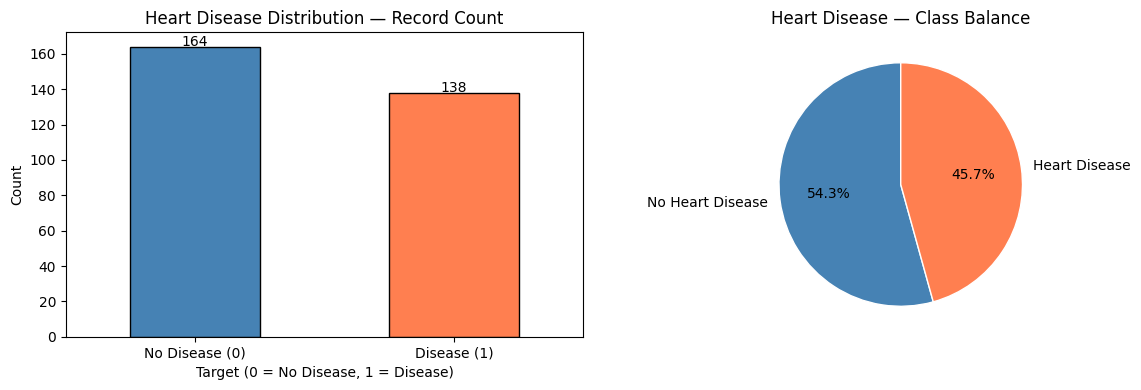

Dataset is nearly balanced ✅


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black'
)
axes[0].set_title('Heart Disease Distribution — Record Count')
axes[0].set_xlabel('Target (0 = No Disease, 1 = Disease)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                     ha='center')

axes[1].pie(
    df['target'].value_counts(),
    labels=['No Heart Disease', 'Heart Disease'],
    colors=['steelblue', 'coral'],
    autopct='%1.1f%%', startangle=90,

    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Heart Disease — Class Balance')
plt.tight_layout()
plt.show()
print("Dataset is nearly balanced ✅")

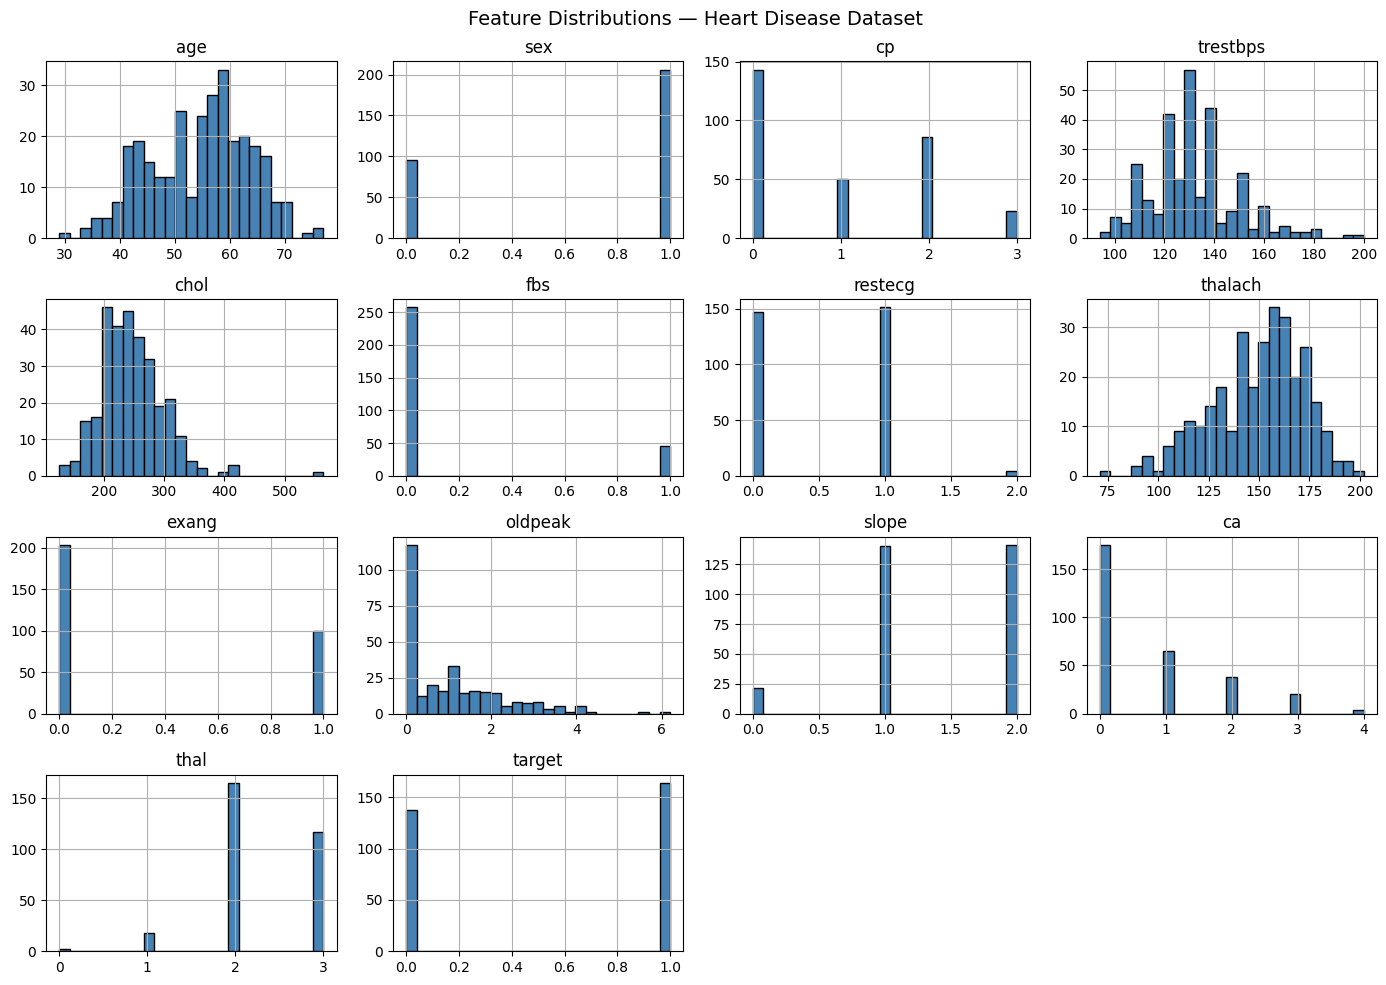

In [ ]:
df.hist(figsize=(14, 10), bins=25, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions — Heart Disease Dataset', fontsize=14)
plt.tight_layout()
plt.show()

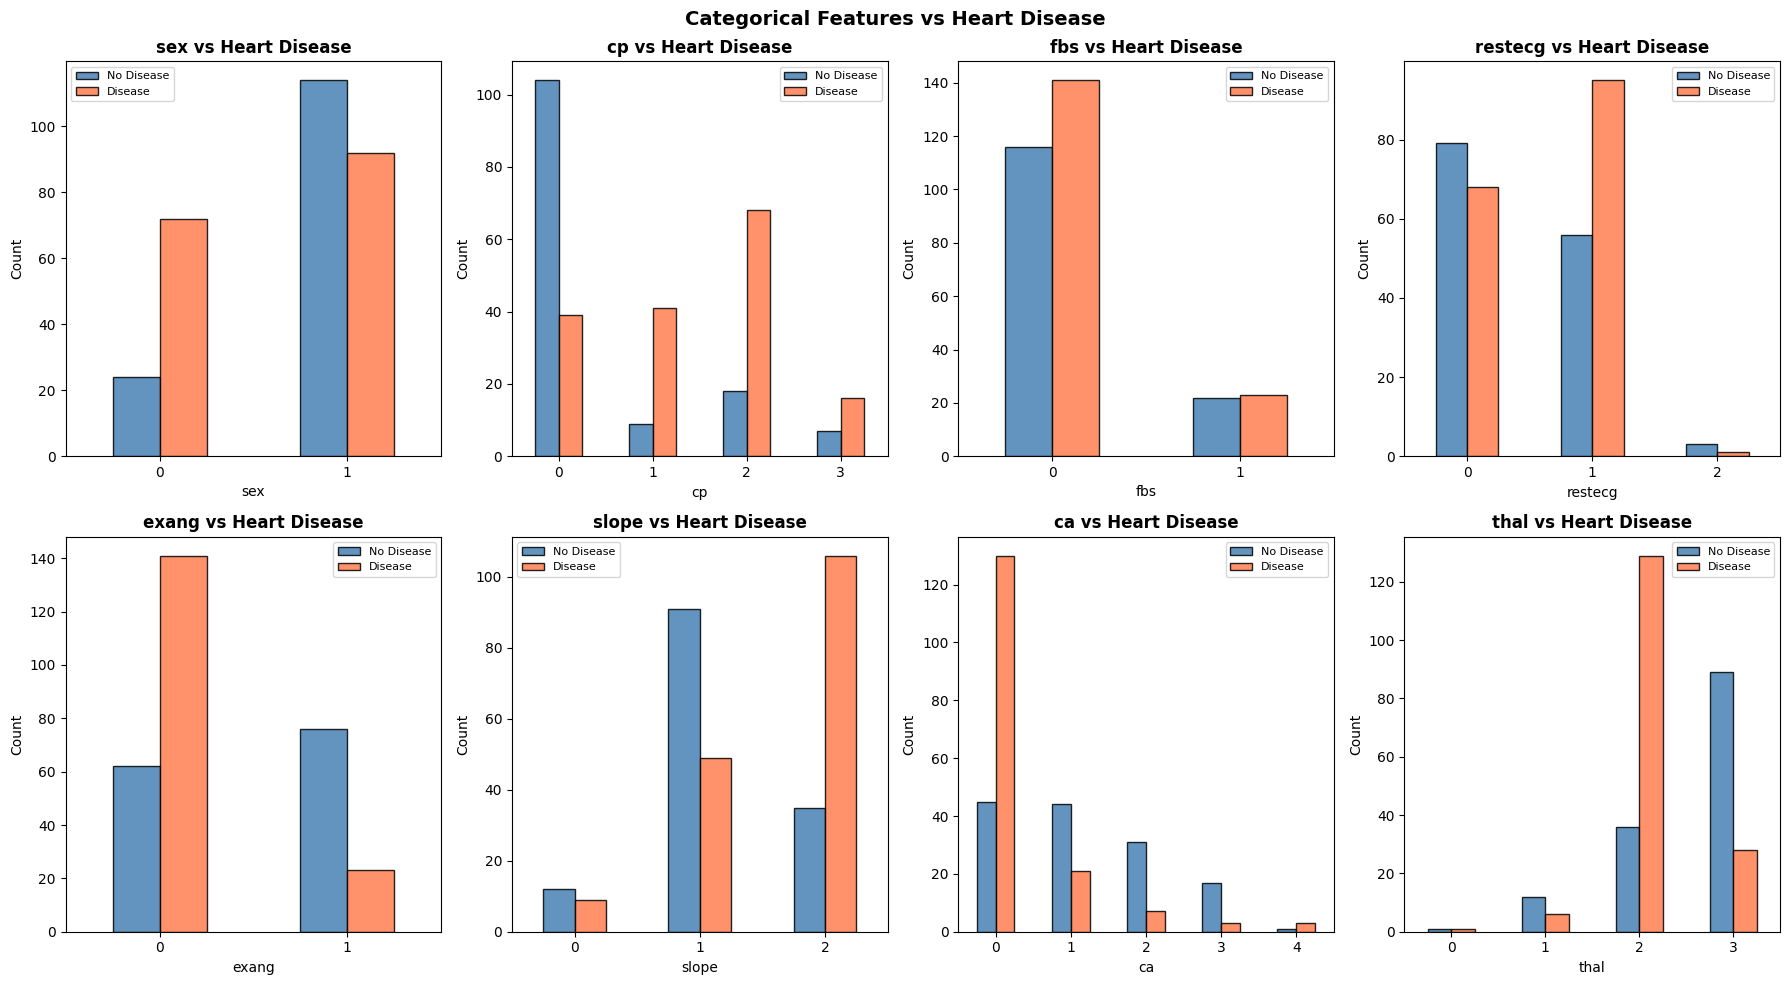

In [ ]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = df.groupby([feat, 'target']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'],
            edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{feat} vs Heart Disease', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

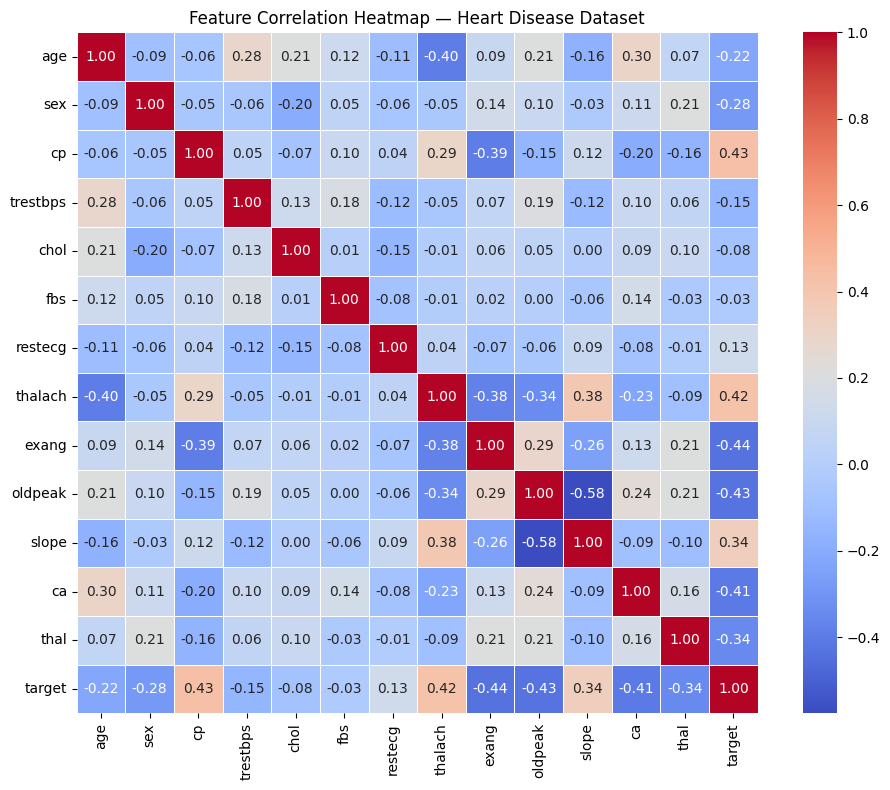

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap — Heart Disease Dataset')
plt.tight_layout()
plt.show()

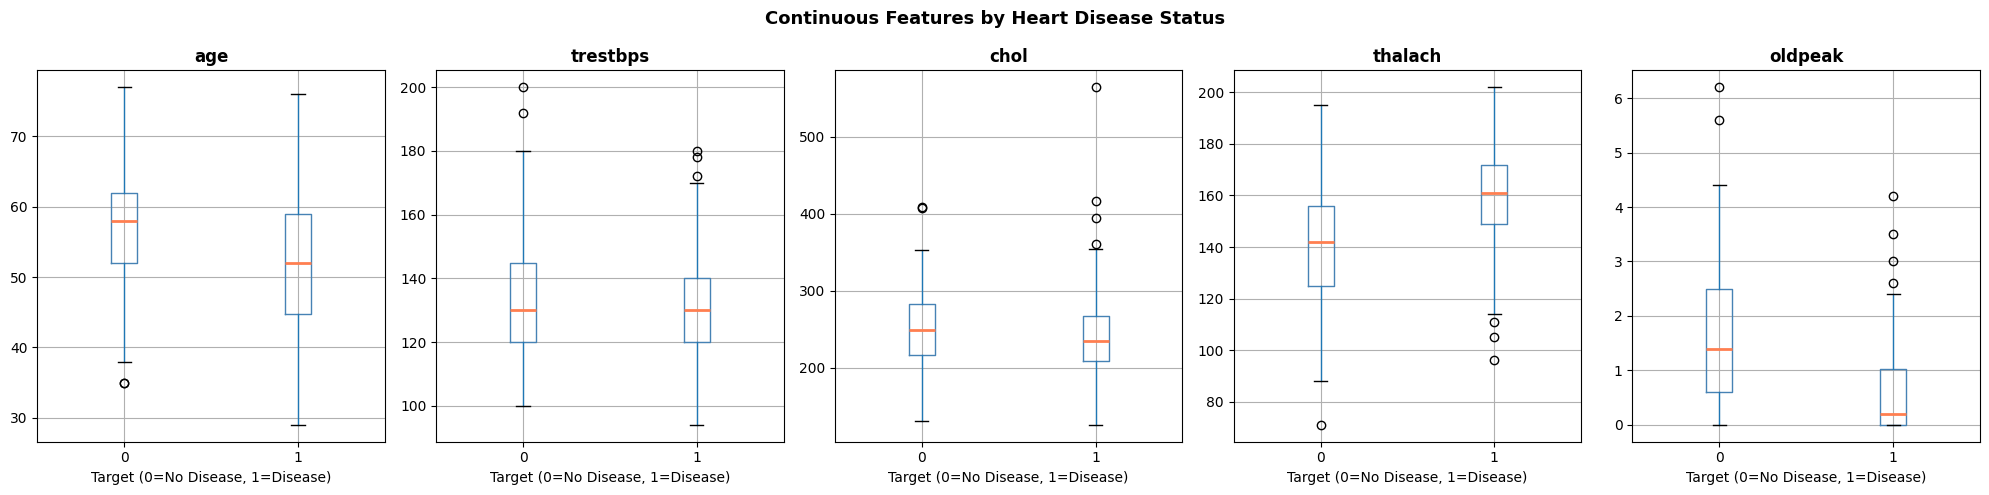

In [ ]:
cont_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, feat in enumerate(cont_features):
    df.boxplot(column=feat, by='target', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='coral', linewidth=2))
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Target (0=No Disease, 1=Disease)')

plt.suptitle('Continuous Features by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Add Gaussian noise to simulate real-world measurement variability
# Prevents the model from memorising sharp boundaries in clean clinical data
np.random.seed(42)
noise_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in noise_cols:
    df[col] = df[col] + np.random.normal(0, df[col].std() * 0.10, len(df))

X = df.drop('target', axis=1)
y = df['target']

print("Features:", list(X.columns))
print("Target  :", y.name)
print("X shape :", X.shape)
print("\n✅ Preprocessing complete")
df.head()

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target  : target
X shape : (302, 13)

✅ Preprocessing complete


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.449425,1,0,126.312501,214.139670,0,1,164.885450,0,0.837094,2,2,3,0
1,52.874899,1,0,141.072017,212.713073,1,0,156.709184,1,3.303205,0,0,3,0
2,70.586027,1,0,144.963290,169.995371,0,1,126.478386,1,2.455531,0,0,3,0
3,62.378033,1,0,148.206067,196.558478,0,1,165.954616,0,-0.080478,2,1,3,0
4,61.788139,0,0,140.244013,284.794502,1,1,105.295079,0,1.816560,1,3,2,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("\nTrain class balance:", y_train.value_counts().to_dict())
print("Test  class balance:", y_test.value_counts().to_dict())

Train size: (241, 13)
Test  size: (61, 13)

Train class balance: {1: 131, 0: 110}
Test  class balance: {1: 33, 0: 28}


In [ ]:
# Logistic Regression requires scaling — gradient descent is sensitive to feature scale
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print("✅ Scaling done")
print(f"   X_train_sc shape: {X_train_sc.shape}")
print(f"   X_test_sc  shape: {X_test_sc.shape}")

✅ Scaling done
   X_train_sc shape: (241, 13)
   X_test_sc  shape: (61, 13)


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000, C=1.0),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100, max_depth=10,
                                min_samples_split=10, min_samples_leaf=4,
                                max_features='sqrt', n_jobs=-1, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(
                                n_estimators=100, max_depth=4,
                                learning_rate=0.1, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes'         : GaussianNB(),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42),
}

needs_scaling = ['Logistic Regression', 'KNN', 'SVM']
results = []

for name, m in models.items():
    if name in needs_scaling:
        m.fit(X_train_sc, y_train)
        y_pred  = m.predict(X_test_sc)
        y_proba = m.predict_proba(X_test_sc)[:, 1]
    else:
        m.fit(X_train, y_train)
        y_pred  = m.predict(X_test)
        y_proba = m.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    results.append({'Model': name,
                    'Accuracy' : round(acc,  4),
                    'Precision': round(prec, 4),
                    'Recall'   : round(rec,  4),
                    'F1 Score' : round(f1,   4),
                    'ROC-AUC'  : round(auc,  4)})
    print(f"{name:22s}  Acc:{acc:.4f}  Prec:{prec:.4f}  Rec:{rec:.4f}  F1:{f1:.4f}  AUC:{auc:.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print()
print(results_df.to_string(index=False))

Logistic Regression     Acc:0.7869  Prec:0.7778  Rec:0.8485  F1:0.8116  AUC:0.8626
Decision Tree           Acc:0.7541  Prec:0.8000  Rec:0.7273  F1:0.7619  AUC:0.7933
Random Forest           Acc:0.7869  Prec:0.7941  Rec:0.8182  F1:0.8060  AUC:0.8528
Gradient Boosting       Acc:0.7541  Prec:0.7812  Rec:0.7576  F1:0.7692  AUC:0.8279
KNN                     Acc:0.8033  Prec:0.8000  Rec:0.8485  F1:0.8235  AUC:0.8582
Naive Bayes             Acc:0.7869  Prec:0.8333  Rec:0.7576  F1:0.7937  AUC:0.8842
SVM                     Acc:0.7541  Prec:0.7500  Rec:0.8182  F1:0.7826  AUC:0.8409

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
        Naive Bayes    0.7869     0.8333  0.7576    0.7937   0.8842
Logistic Regression    0.7869     0.7778  0.8485    0.8116   0.8626
                KNN    0.8033     0.8000  0.8485    0.8235   0.8582
      Random Forest    0.7869     0.7941  0.8182    0.8060   0.8528
                SVM    0.7541     0.7500  0.8182    0.7826   0.8409
  Gradient

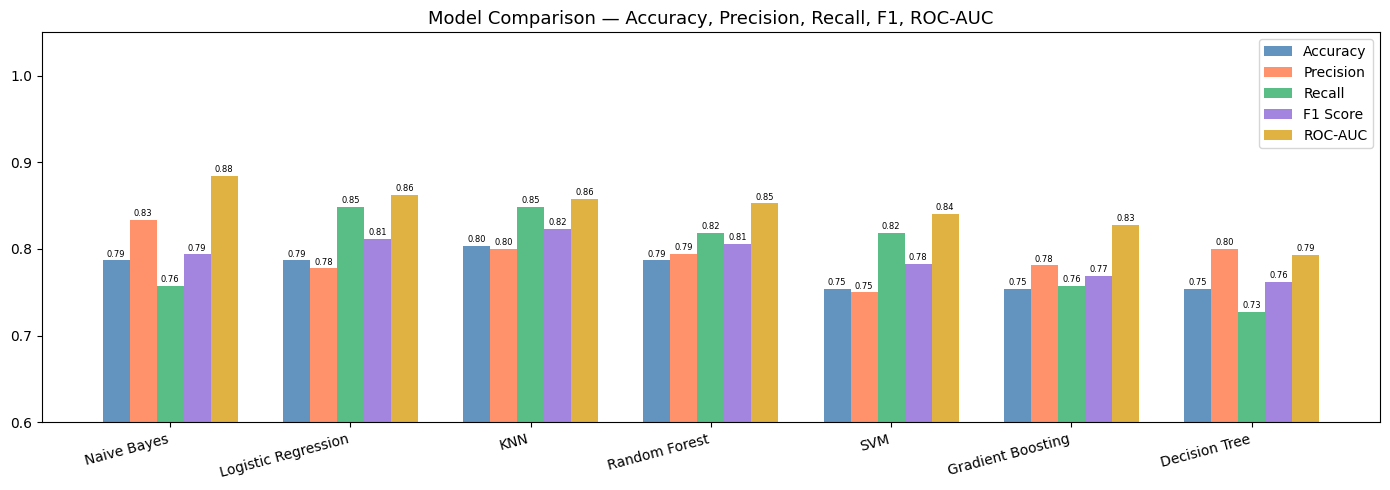

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
x       = np.arange(len(results_df))
width   = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors  = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.60, 1.05)
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1, ROC-AUC', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

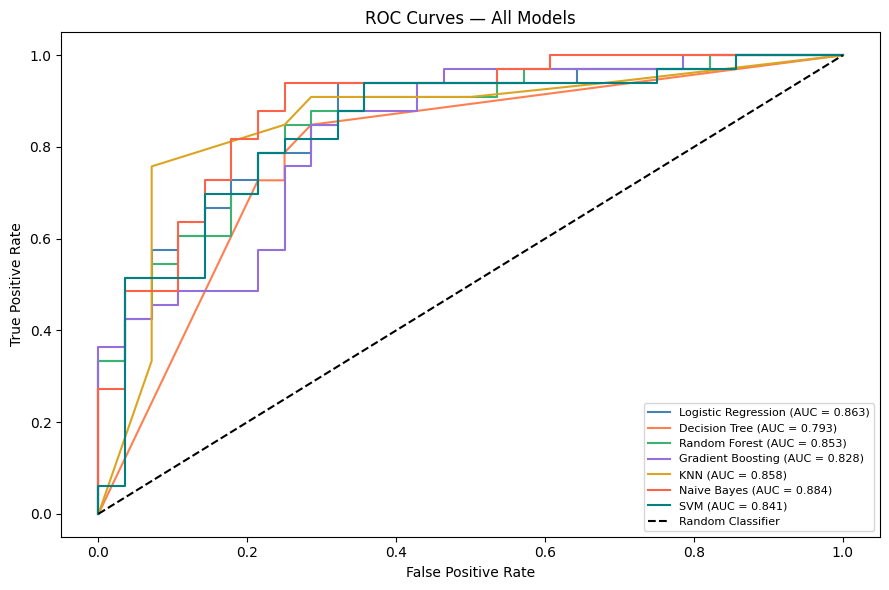

In [ ]:
plt.figure(figsize=(9, 6))
colors_roc = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple',
               'goldenrod', 'tomato', 'teal']

for (name, m), color in zip(models.items(), colors_roc):
    yp = m.predict_proba(X_test_sc if name in needs_scaling else X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
best_model  = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_sc)

print("✅ Best Model Selected: Logistic Regression")
print(f"   Test Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"   F1 Score      : {f1_score(y_test, y_pred_best):.4f}")
print(f"   ROC-AUC       : {roc_auc_score(y_test, best_model.predict_proba(X_test_sc)[:, 1]):.4f}")

✅ Best Model Selected: Logistic Regression
   Test Accuracy : 0.7869
   F1 Score      : 0.8116
   ROC-AUC       : 0.8626


Classification Report — Logistic Regression:
                   precision    recall  f1-score   support

   No Disease (0)       0.80      0.71      0.75        28
Heart Disease (1)       0.78      0.85      0.81        33

         accuracy                           0.79        61
        macro avg       0.79      0.78      0.78        61
     weighted avg       0.79      0.79      0.79        61



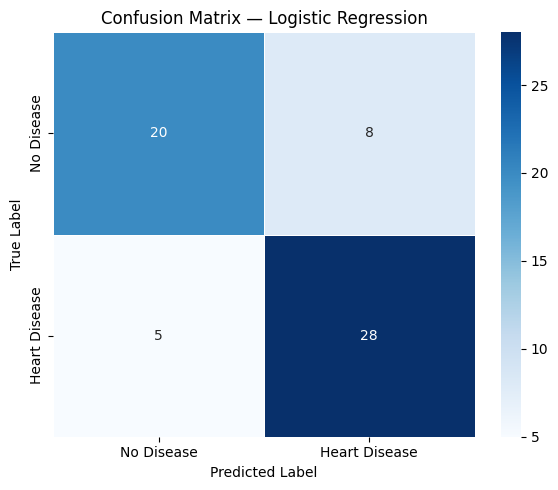


True  Negatives (Correctly said No Disease) : 20
False Positives (Wrongly said Disease)      : 8
False Negatives (Missed Disease — CRITICAL) : 5
True  Positives (Correctly said Disease)    : 28


In [ ]:
y_pred = best_model.predict(X_test_sc)

print("Classification Report — Logistic Regression:")
print(classification_report(y_test, y_pred,
                             target_names=['No Disease (0)', 'Heart Disease (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            linewidths=0.5)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (Correctly said No Disease) : {tn}")
print(f"False Positives (Wrongly said Disease)      : {fp}")
print(f"False Negatives (Missed Disease — CRITICAL) : {fn}")
print(f"True  Positives (Correctly said Disease)    : {tp}")

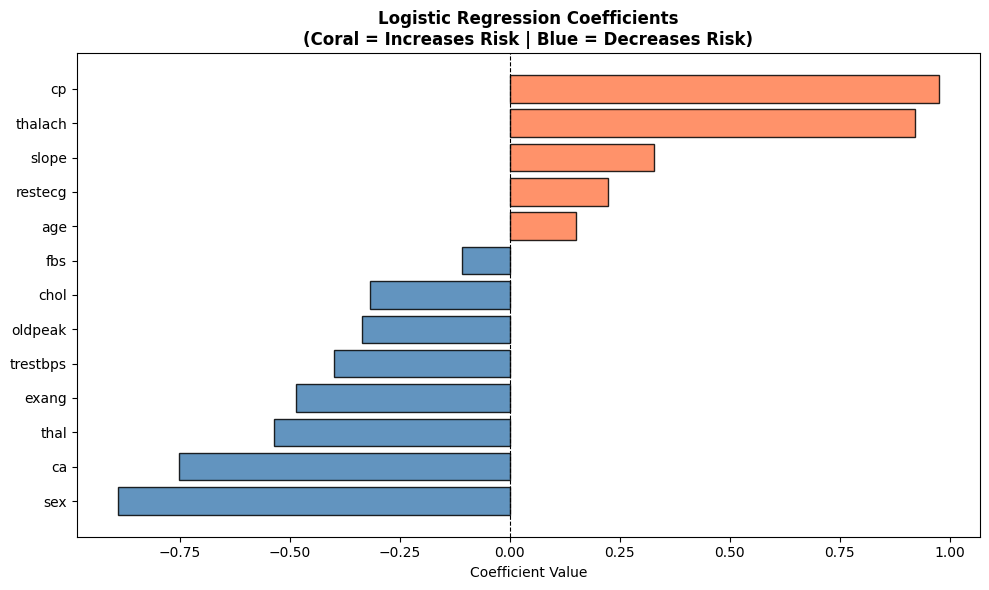


Coefficients sorted by impact:
 Feature  Coefficient
      cp     0.975642
 thalach     0.921027
     sex    -0.891203
      ca    -0.752423
    thal    -0.535927
   exang    -0.486756
trestbps    -0.398996
 oldpeak    -0.334857
   slope     0.328761
    chol    -0.317834
 restecg     0.222867
     age     0.149596
     fbs    -0.108431


In [ ]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
bar_colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'],
         color=bar_colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression Coefficients\n(Coral = Increases Risk | Blue = Decreases Risk)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

coef_sorted = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print("\nCoefficients sorted by impact:")
print(coef_sorted.to_string(index=False))

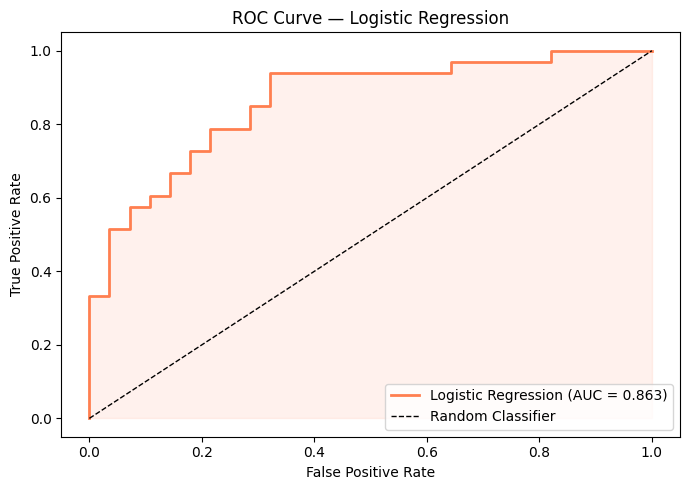

In [ ]:
y_proba_lr = best_model.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='coral', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='coral')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
X_scaled_all = StandardScaler().fit_transform(X)
lr_cv = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
cv_scores = cross_val_score(lr_cv, X_scaled_all, y, cv=5, scoring='roc_auc')

print("Cross-Validation — Logistic Regression (5-Fold ROC-AUC):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")
print("\n✅ Model is stable — low std confirms no overfitting")

Cross-Validation — Logistic Regression (5-Fold ROC-AUC):
  Fold 1: 0.8950
  Fold 2: 0.8896
  Fold 3: 0.9788
  Fold 4: 0.8855
  Fold 5: 0.8227

  Mean : 0.8943
  Std  : 0.0497

✅ Model is stable — low std confirms no overfitting


In [ ]:
joblib.dump(best_model, '/content/drive/MyDrive/heart_lr_model.pkl')
joblib.dump(scaler,     '/content/drive/MyDrive/heart_lr_scaler.pkl')

with open('heart_lr_feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

print("✅ Model saved    → heart_lr_model.pkl")
print("✅ Scaler saved   → heart_lr_scaler.pkl")
print("✅ Features saved → heart_lr_feature_columns.json")

✅ Model saved    → heart_lr_model.pkl
✅ Scaler saved   → heart_lr_scaler.pkl
✅ Features saved → heart_lr_feature_columns.json


In [ ]:
def predict_heart_risk(patient_data):
    loaded_model  = joblib.load('/content/drive/MyDrive/heart_lr_model.pkl')
    loaded_scaler = joblib.load('/content/drive/MyDrive/heart_lr_scaler.pkl')

    with open('heart_lr_feature_columns.json') as f:
        feature_cols = json.load(f)

    input_df     = pd.DataFrame([patient_data])
    input_df     = input_df.reindex(columns=feature_cols, fill_value=0)
    input_scaled = loaded_scaler.transform(input_df)  # ⚠️ must scale before predict

    pred       = loaded_model.predict(input_scaled)[0]
    proba      = loaded_model.predict_proba(input_scaled)[0]
    risk_label = "❤️  HEART DISEASE DETECTED" if pred == 1 else "✅ NO HEART DISEASE"
    confidence = proba[pred]

    return (
        f"Prediction  : {risk_label}\n"
        f"Confidence  : {confidence:.2%}\n"
        f"Disease Prob: {proba[1]:.2%}  |  No Disease Prob: {proba[0]:.2%}"
    )

print("✅ predict_heart_risk() is ready")

✅ predict_heart_risk() is ready


In [ ]:
print("=" * 50)
print("Test Case 1 — High Risk Patient")
print("=" * 50)
print(predict_heart_risk({
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145,
    'chol': 233, 'fbs': 1, 'restecg': 0,
    'thalach': 150, 'exang': 0, 'oldpeak': 2.3,
    'slope': 0, 'ca': 0, 'thal': 1
}))

Test Case 1 — High Risk Patient
Prediction  : ❤️  HEART DISEASE DETECTED
Confidence  : 83.59%
Disease Prob: 83.59%  |  No Disease Prob: 16.41%


In [ ]:
print("=" * 50)
print("Test Case 2 — Low Risk Patient")
print("=" * 50)
print(predict_heart_risk({
    'age': 41, 'sex': 0, 'cp': 1, 'trestbps': 130,
    'chol': 204, 'fbs': 0, 'restecg': 0,
    'thalach': 172, 'exang': 0, 'oldpeak': 1.4,
    'slope': 2, 'ca': 0, 'thal': 2
}))

Test Case 2 — Low Risk Patient
Prediction  : ❤️  HEART DISEASE DETECTED
Confidence  : 97.03%
Disease Prob: 97.03%  |  No Disease Prob: 2.97%


In [ ]:
print("=" * 50)
print("Test Case 3 — Custom Patient")
print("=" * 50)
print(predict_heart_risk({
    'age': 55, 'sex': 1, 'cp': 0, 'trestbps': 160,
    'chol': 289, 'fbs': 0, 'restecg': 1,
    'thalach': 145, 'exang': 1, 'oldpeak': 1.8,
    'slope': 1, 'ca': 1, 'thal': 3
}))

Test Case 3 — Custom Patient
Prediction  : ✅ NO HEART DISEASE
Confidence  : 98.70%
Disease Prob: 1.30%  |  No Disease Prob: 98.70%


In [ ]:
from google.colab import files
files.download('heart_lr_feature_columns.json')
files.download('/content/drive/MyDrive/heart_lr_model.pkl')
files.download('/content/drive/MyDrive/heart_lr_scaler.pkl')
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
